# Memory MRE Analysis

Reads JSONL output from `loadgen/ramp.ts` and visualizes memory behavior under load.

Set `RUN_A` to a baseline run. Optionally set `RUN_B` to a patched run for A/B comparison.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

# ── Configure runs ──
RUN_A = "results/baseline.jsonl"   # required
RUN_B = "results/patched-langsmith.jsonl"    # optional: set to "results/patched.jsonl" for A/B

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

In [2]:
def load_run(path):
    """Load JSONL into a list of dicts, then split into typed DataFrames."""
    events = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            events.append(json.loads(line))
    
    all_df = pd.DataFrame(events)
    
    # Normalize time to seconds from start
    t0 = all_df['t'].min() if 't' in all_df.columns else 0
    if 't' in all_df.columns:
        all_df['t_s'] = (all_df['t'] - t0) / 1000.0
    
    docker = all_df[all_df['ev'] == 'docker_stats'].copy() if 'ev' in all_df.columns else pd.DataFrame()
    app = all_df[all_df['ev'] == 'app_metrics'].copy() if 'ev' in all_df.columns else pd.DataFrame()
    requests = all_df[all_df['ev'] == 'request_end'].copy() if 'ev' in all_df.columns else pd.DataFrame()
    levels = all_df[all_df['ev'].isin(['level_start', 'level_end'])].copy() if 'ev' in all_df.columns else pd.DataFrame()
    ramp_stop = all_df[all_df['ev'] == 'ramp_stop'].copy() if 'ev' in all_df.columns else pd.DataFrame()
    
    return {
        'all': all_df,
        'docker': docker,
        'app': app,
        'requests': requests,
        'levels': levels,
        'ramp_stop': ramp_stop,
        't0': t0,
        'path': path,
    }

run_a = load_run(RUN_A)
run_b = load_run(RUN_B) if RUN_B else None
print(f"Run A: {RUN_A} — {len(run_a['all'])} events")
if run_b:
    print(f"Run B: {RUN_B} — {len(run_b['all'])} events")

Run A: results/baseline.jsonl — 591 events
Run B: results/patched-langsmith.jsonl — 245 events


## 1. Memory Timeline

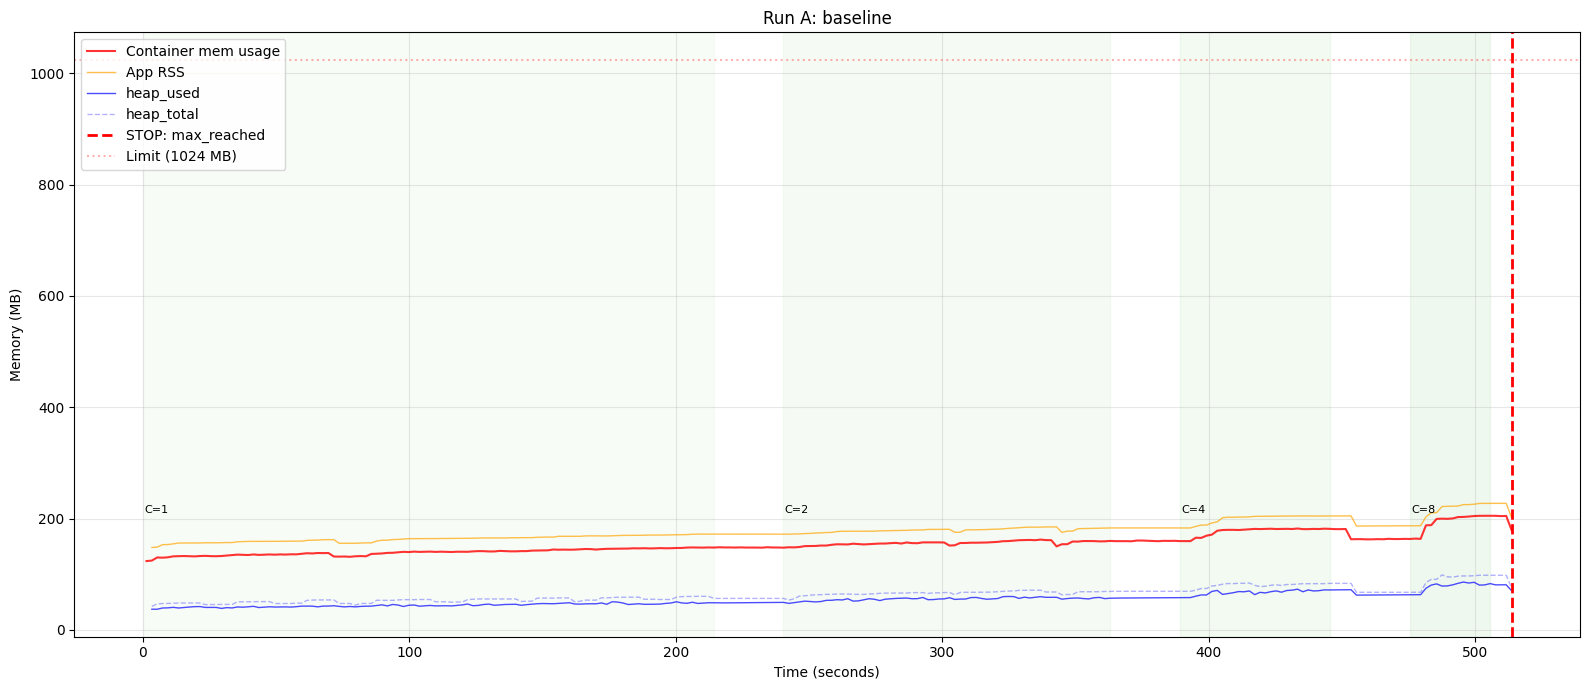

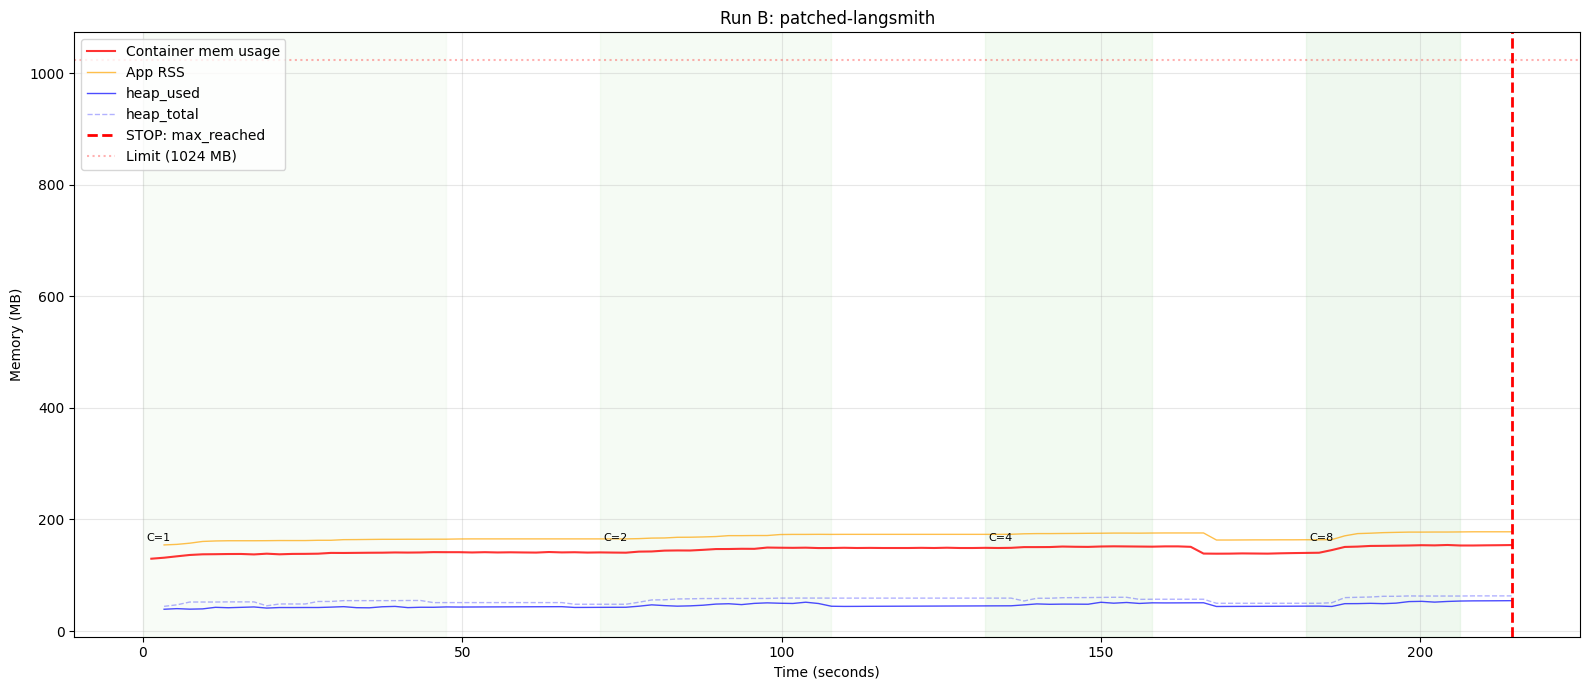

In [3]:
def plot_memory_timeline(run, title="Memory Timeline"):
    fig, ax = plt.subplots(figsize=(16, 7))
    
    # Docker container memory
    docker = run['docker']
    if not docker.empty and 'container_mem_usage_mb' in docker.columns:
        ax.plot(docker['t_s'], docker['container_mem_usage_mb'],
                label='Container mem usage', color='red', alpha=0.8, linewidth=1.5)
    
    # App-level metrics
    app = run['app']
    if not app.empty:
        if 'rss' in app.columns:
            ax.plot(app['t_s'], app['rss'] / 1024 / 1024,
                    label='App RSS', color='orange', alpha=0.7, linewidth=1)
        if 'heap_used' in app.columns:
            ax.plot(app['t_s'], app['heap_used'] / 1024 / 1024,
                    label='heap_used', color='blue', alpha=0.7, linewidth=1)
        if 'heap_total' in app.columns:
            ax.plot(app['t_s'], app['heap_total'] / 1024 / 1024,
                    label='heap_total', color='blue', alpha=0.3, linewidth=1, linestyle='--')
    
    # Ramp level bands
    levels = run['levels']
    colors = plt.cm.Greens(np.linspace(0.2, 0.8, 10))
    if not levels.empty:
        starts = levels[levels['ev'] == 'level_start']
        ends = levels[levels['ev'] == 'level_end']
        for _, start_row in starts.iterrows():
            lidx = start_row.get('level_idx', 0)
            conc = start_row.get('concurrency', 1)
            end_rows = ends[ends.get('level_idx', pd.Series()) == lidx]
            t_end = end_rows['t_s'].iloc[0] if not end_rows.empty else start_row['t_s'] + 10
            color = colors[int(lidx) % len(colors)]
            ax.axvspan(start_row['t_s'], t_end, alpha=0.15, color=color)
            ax.text(start_row['t_s'] + 0.5, ax.get_ylim()[1] * 0.95,
                    f'C={int(conc)}', fontsize=8, va='top')
    
    # OOM/failure line
    ramp_stop = run['ramp_stop']
    if not ramp_stop.empty:
        reason = ramp_stop.iloc[0].get('reason', '')
        ax.axvline(ramp_stop.iloc[0]['t_s'], color='red', linestyle='--',
                   linewidth=2, label=f'STOP: {reason}')
    
    # Container limit line
    if not docker.empty and 'container_mem_limit_mb' in docker.columns:
        limit = docker['container_mem_limit_mb'].iloc[0]
        if limit > 0:
            ax.axhline(limit, color='red', alpha=0.3, linestyle=':', label=f'Limit ({limit:.0f} MB)')
    
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Memory (MB)')
    ax.set_title(title)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

plot_memory_timeline(run_a, f"Run A: {Path(RUN_A).stem}")
plt.show()

if run_b:
    plot_memory_timeline(run_b, f"Run B: {Path(RUN_B).stem}")
    plt.show()

## 2. Request Latency Distribution

/var/folders/j4/cz00grtx5nxdjcxw3cysv7zm0000gn/T/ipykernel_54673/1572561102.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(c) for c in conc_levels], patch_artist=True)


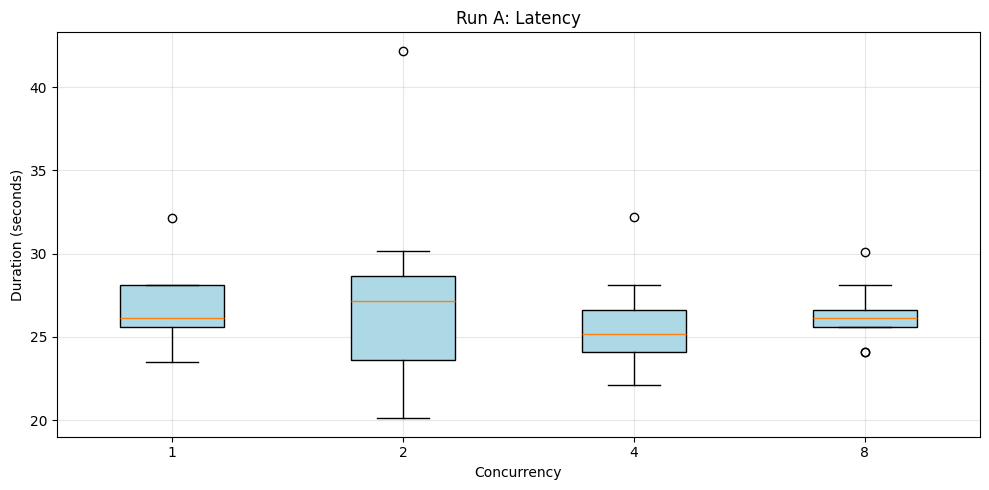

/var/folders/j4/cz00grtx5nxdjcxw3cysv7zm0000gn/T/ipykernel_54673/1572561102.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(c) for c in conc_levels], patch_artist=True)


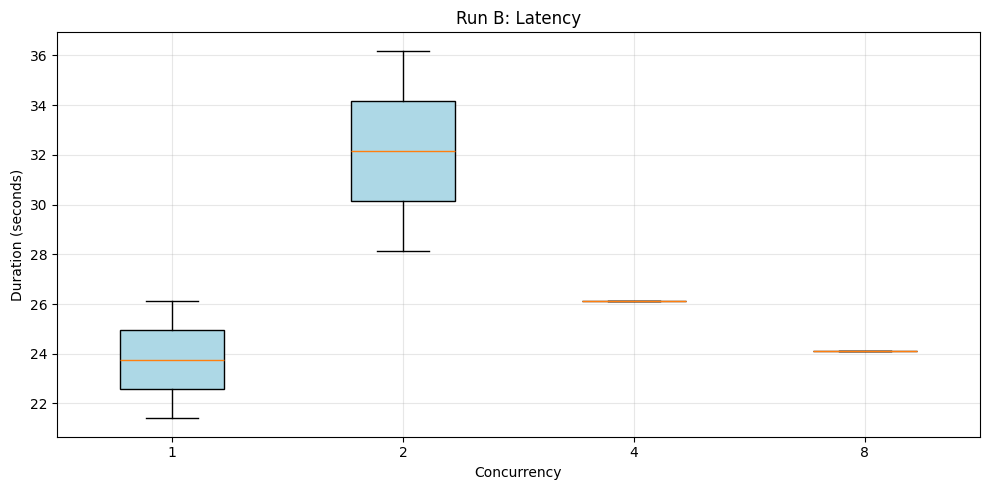

In [5]:
def plot_latency_boxplot(run, title="Request Latency by Concurrency"):
    reqs = run['requests']
    if reqs.empty or 'duration_ms' not in reqs.columns:
        print("No request data")
        return
    
    reqs = reqs.copy()
    reqs['duration_s'] = reqs['duration_ms'] / 1000.0
    reqs['concurrency'] = reqs['concurrency'].astype(int)
    
    conc_levels = sorted(reqs['concurrency'].unique())
    data = [reqs[reqs['concurrency'] == c]['duration_s'].values for c in conc_levels]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    bp = ax.boxplot(data, labels=[str(c) for c in conc_levels], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    ax.set_xlabel('Concurrency')
    ax.set_ylabel('Duration (seconds)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

plot_latency_boxplot(run_a, f"Run A: Latency")
plt.show()

if run_b:
    plot_latency_boxplot(run_b, f"Run B: Latency")
    plt.show()

## 4. Container Memory Utilization

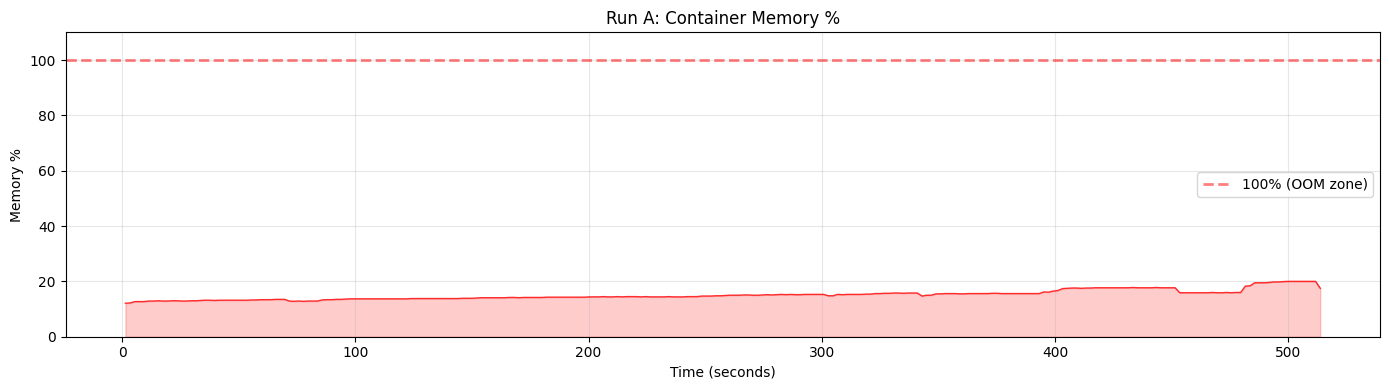

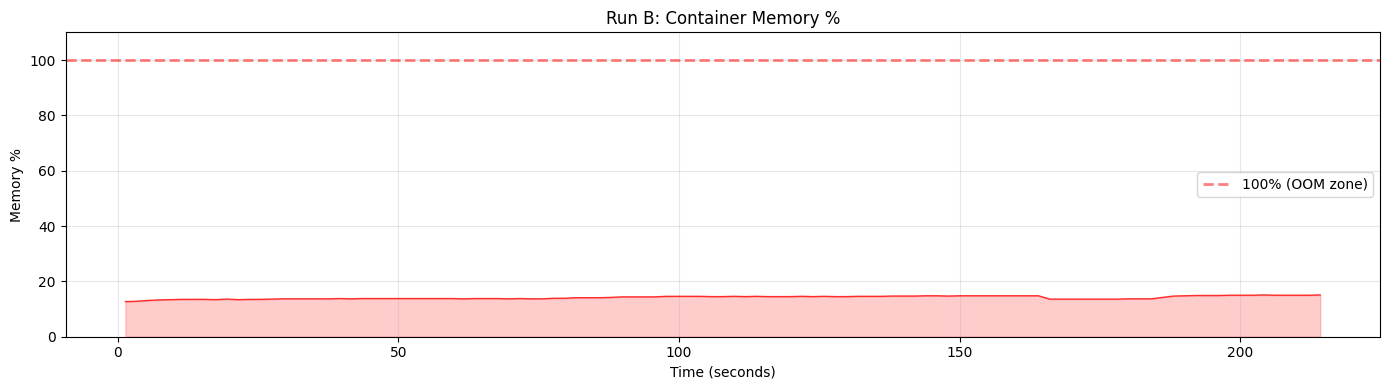

In [6]:
def plot_utilization(run, title="Container Memory Utilization"):
    docker = run['docker']
    if docker.empty or 'container_mem_pct' not in docker.columns:
        print("No docker stats")
        return
    
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(docker['t_s'], docker['container_mem_pct'],
            color='red', alpha=0.8, linewidth=1)
    ax.axhline(100, color='red', linestyle='--', linewidth=2, alpha=0.5, label='100% (OOM zone)')
    ax.fill_between(docker['t_s'], docker['container_mem_pct'], alpha=0.2, color='red')
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Memory %')
    ax.set_title(title)
    ax.set_ylim(0, 110)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

plot_utilization(run_a, f"Run A: Container Memory %")
plt.show()

if run_b:
    plot_utilization(run_b, f"Run B: Container Memory %")
    plt.show()

## 5. Level Summary Table

In [7]:
def level_summary(run):
    """Build a per-level summary table."""
    reqs = run['requests']
    levels = run['levels']
    if reqs.empty:
        return pd.DataFrame()
    
    reqs = reqs.copy()
    reqs['concurrency'] = reqs['concurrency'].astype(int)
    
    def get_mem(row, key):
        mem = row.get('memory')
        if isinstance(mem, dict):
            return mem.get(key, 0)
        return 0
    
    reqs['peak_heap'] = reqs.apply(lambda r: get_mem(r, 'peak_heap_mb'), axis=1)
    reqs['peak_rss'] = reqs.apply(lambda r: get_mem(r, 'peak_rss_mb'), axis=1)
    
    rows = []
    for conc in sorted(reqs['concurrency'].unique()):
        subset = reqs[reqs['concurrency'] == conc]
        ok = subset[subset['ok'] == True]
        failed = subset[subset['ok'] == False]
        rows.append({
            'Concurrency': conc,
            'Requests': len(subset),
            'OK': len(ok),
            'Failed': len(failed),
            'p50 (s)': round(ok['duration_ms'].quantile(0.5) / 1000, 1) if len(ok) else None,
            'p95 (s)': round(ok['duration_ms'].quantile(0.95) / 1000, 1) if len(ok) else None,
            'Peak Heap (MB)': round(subset['peak_heap'].max(), 1),
            'Peak RSS (MB)': round(subset['peak_rss'].max(), 1),
        })
    
    # Add stop reason
    stop = run['ramp_stop']
    stop_reason = stop.iloc[0].get('reason', '?') if not stop.empty else '?'
    
    df = pd.DataFrame(rows)
    print(f"Stop reason: {stop_reason}")
    return df

print("=== Run A ===")
summary_a = level_summary(run_a)
display(summary_a)

if run_b:
    print("\n=== Run B ===")
    summary_b = level_summary(run_b)
    display(summary_b)

=== Run A ===
Stop reason: max_reached


,Concurrency,Requests,OK,Failed,p50 (s),p95 (s),Peak Heap (MB),Peak RSS (MB)
0,1,8,8,0,26.1,30.7,0,0
1,2,8,8,0,27.1,38.0,0,0
2,4,8,8,0,25.1,30.8,0,0
3,8,8,8,0,26.1,29.4,0,0



=== Run B ===
Stop reason: max_reached


,Concurrency,Requests,OK,Failed,p50 (s),p95 (s),Peak Heap (MB),Peak RSS (MB)
0,1,2,2,0,23.8,25.9,0,0
1,2,2,2,0,32.2,35.8,0,0
2,4,2,2,0,26.1,26.1,0,0
3,8,2,2,0,24.1,24.1,0,0


## 6. Subgraph / Agent Fan-Out

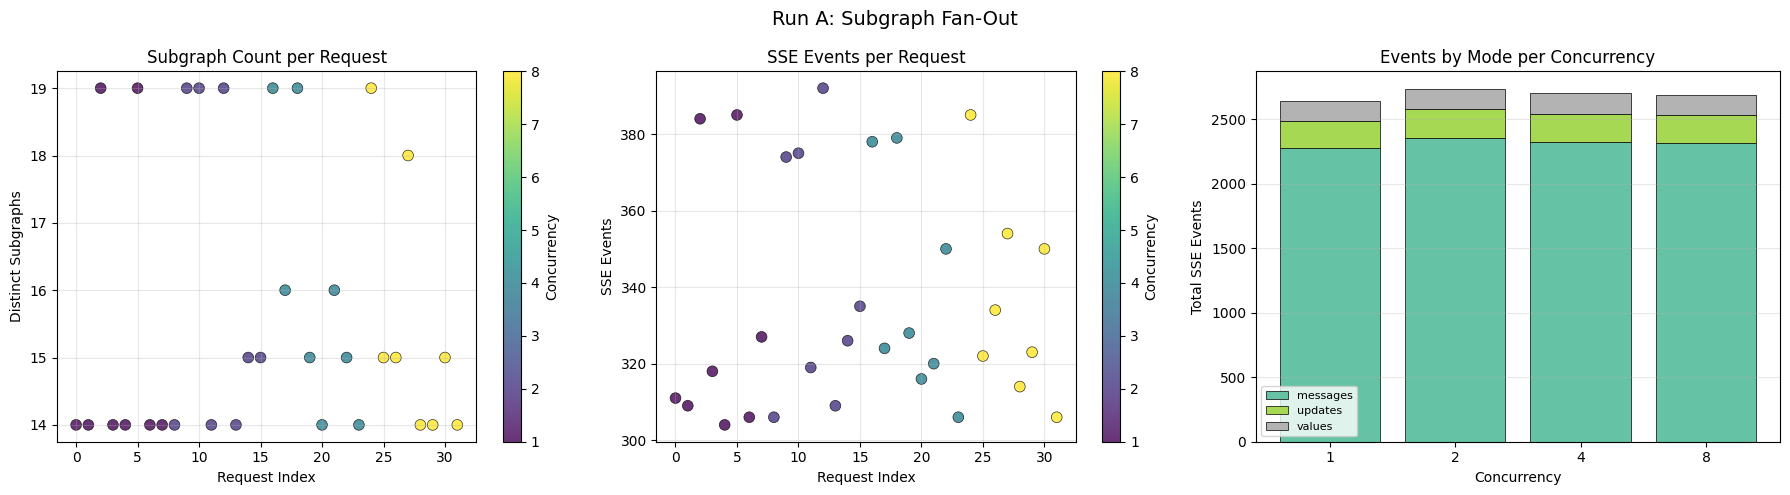

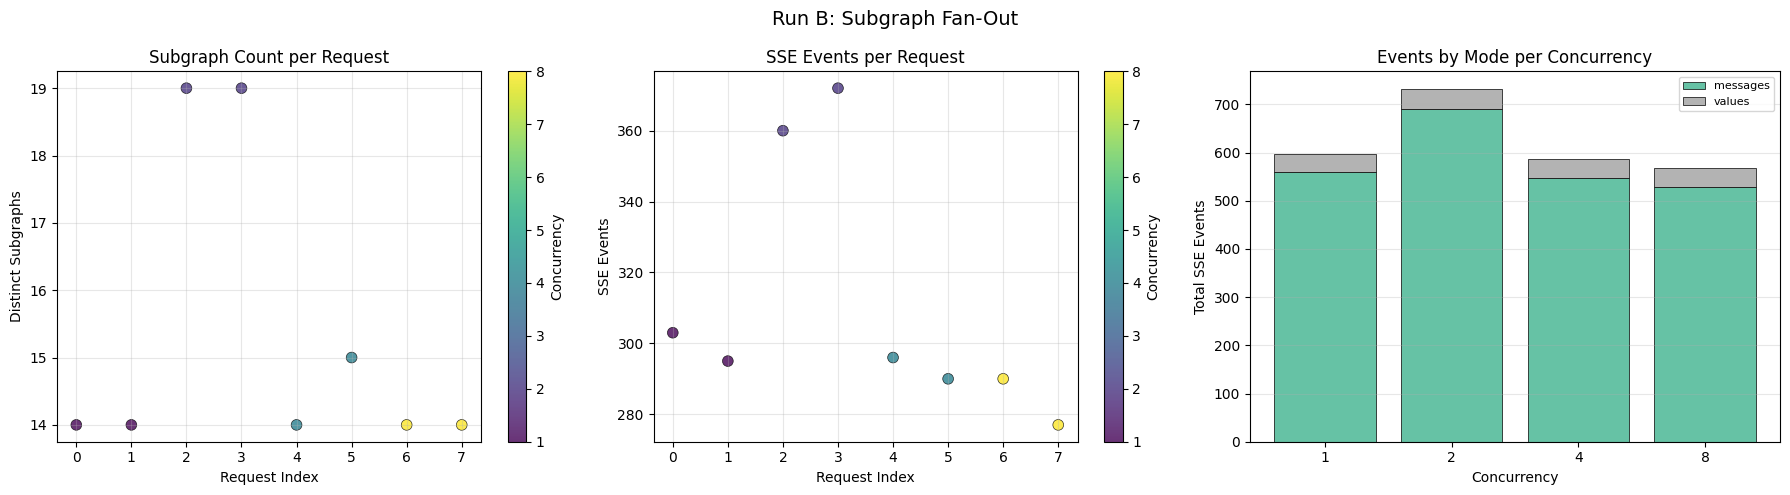

In [8]:
def plot_subgraphs(run, title='Subgraph Fan-Out'):
    reqs = run['requests']
    if reqs.empty or 'subgraph_count' not in reqs.columns:
        print('No subgraph data (re-run loadgen with latest ramp.ts)')
        return
    
    reqs = reqs.copy()
    reqs['concurrency'] = reqs['concurrency'].astype(int)
    reqs['subgraph_count'] = reqs['subgraph_count'].fillna(0).astype(int)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Subgraph count per request, colored by concurrency
    ax = axes[0]
    sc = ax.scatter(reqs['request_idx'], reqs['subgraph_count'],
                    c=reqs['concurrency'], cmap='viridis', s=60, alpha=0.8,
                    edgecolors='black', linewidth=0.5)
    plt.colorbar(sc, ax=ax, label='Concurrency')
    ax.set_xlabel('Request Index')
    ax.set_ylabel('Distinct Subgraphs')
    ax.set_title('Subgraph Count per Request')
    ax.grid(True, alpha=0.3)
    
    # 2. SSE events per request, colored by concurrency
    ax = axes[1]
    if 'sse_events' in reqs.columns:
        sc2 = ax.scatter(reqs['request_idx'], reqs['sse_events'].fillna(0),
                         c=reqs['concurrency'], cmap='viridis', s=60, alpha=0.8,
                         edgecolors='black', linewidth=0.5)
        plt.colorbar(sc2, ax=ax, label='Concurrency')
    ax.set_xlabel('Request Index')
    ax.set_ylabel('SSE Events')
    ax.set_title('SSE Events per Request')
    ax.grid(True, alpha=0.3)
    
    # 3. Breakdown of SSE events by mode (stacked bar, aggregated per concurrency level)
    ax = axes[2]
    if 'events_by_mode' in reqs.columns:
        mode_data = {}
        for _, row in reqs.iterrows():
            ebm = row.get('events_by_mode')
            conc = row['concurrency']
            if isinstance(ebm, dict):
                for mode, count in ebm.items():
                    if mode not in mode_data:
                        mode_data[mode] = {}
                    mode_data[mode][conc] = mode_data[mode].get(conc, 0) + count
        
        if mode_data:
            conc_levels = sorted(set(c for m in mode_data.values() for c in m.keys()))
            bottom = np.zeros(len(conc_levels))
            colors = plt.cm.Set2(np.linspace(0, 1, len(mode_data)))
            for i, (mode, counts) in enumerate(sorted(mode_data.items())):
                vals = [counts.get(c, 0) for c in conc_levels]
                ax.bar([str(c) for c in conc_levels], vals, bottom=bottom,
                       label=mode, color=colors[i], edgecolor='black', linewidth=0.5)
                bottom += np.array(vals)
            ax.legend(fontsize=8)
    ax.set_xlabel('Concurrency')
    ax.set_ylabel('Total SSE Events')
    ax.set_title('Events by Mode per Concurrency')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    return fig

plot_subgraphs(run_a, f'Run A: Subgraph Fan-Out')
plt.show()

if run_b:
    plot_subgraphs(run_b, f'Run B: Subgraph Fan-Out')
    plt.show()

## 7. A/B Comparison (if RUN_B is set)

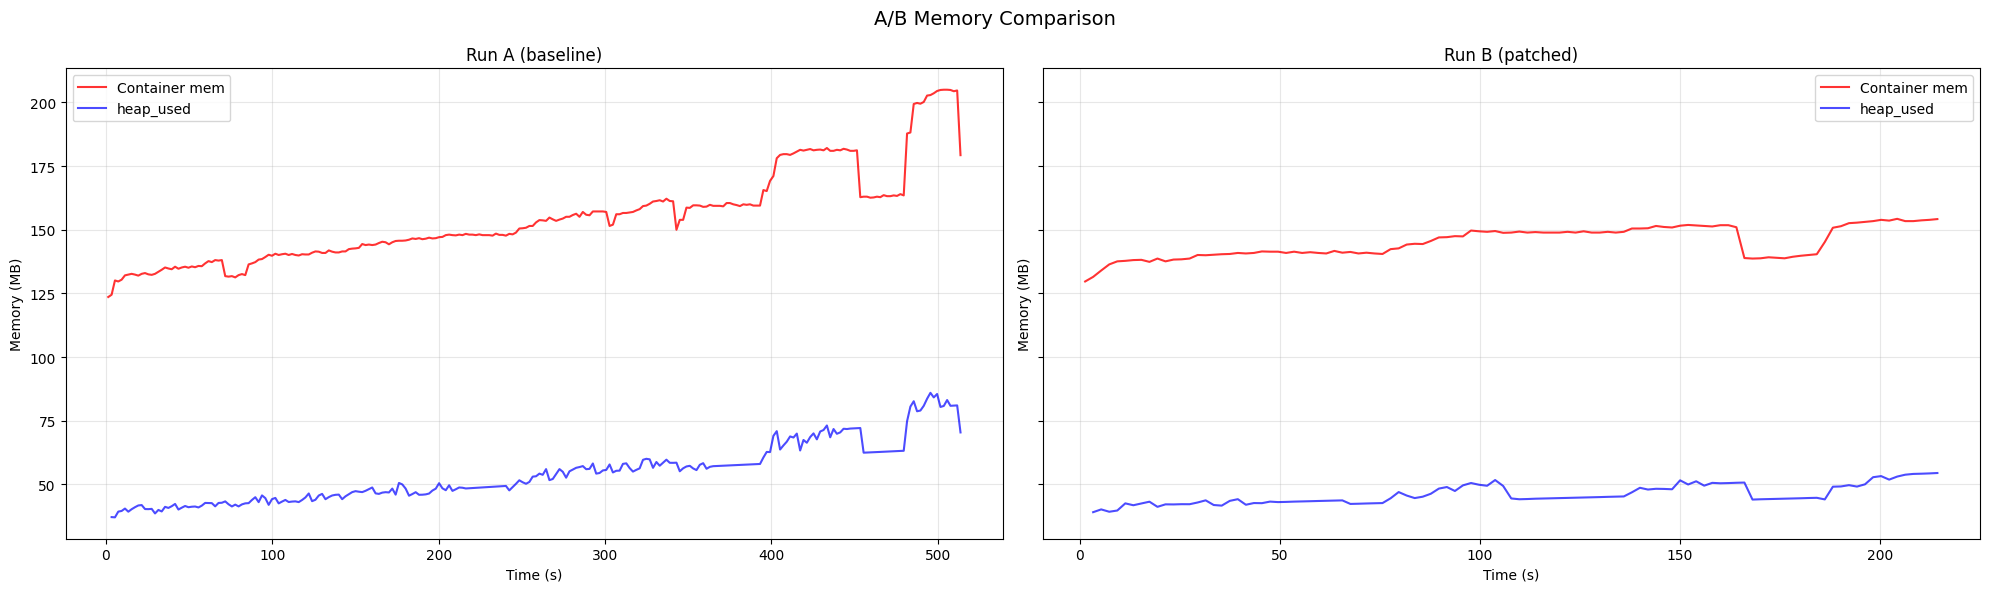

,Concurrency,Requests (A),OK (A),Failed (A),p50 (s) (A),p95 (s) (A),Peak Heap (MB) (A),Peak RSS (MB) (A),Requests (B),OK (B),Failed (B),p50 (s) (B),p95 (s) (B),Peak Heap (MB) (B),Peak RSS (MB) (B)
0,1,8,8,0,26.1,30.7,0,0,2,2,0,23.8,25.9,0,0
1,2,8,8,0,27.1,38.0,0,0,2,2,0,32.2,35.8,0,0
2,4,8,8,0,25.1,30.8,0,0,2,2,0,26.1,26.1,0,0
3,8,8,8,0,26.1,29.4,0,0,2,2,0,24.1,24.1,0,0


In [9]:
if run_b:
    # Side-by-side memory timelines
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6), sharey=True)
    
    for ax, run, label in [(ax1, run_a, 'A (baseline)'), (ax2, run_b, 'B (patched)')]:
        docker = run['docker']
        app = run['app']
        if not docker.empty and 'container_mem_usage_mb' in docker.columns:
            ax.plot(docker['t_s'], docker['container_mem_usage_mb'],
                    label='Container mem', color='red', alpha=0.8)
        if not app.empty and 'heap_used' in app.columns:
            ax.plot(app['t_s'], app['heap_used'] / 1024 / 1024,
                    label='heap_used', color='blue', alpha=0.7)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Memory (MB)')
        ax.set_title(f'Run {label}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('A/B Memory Comparison', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Delta table
    if not summary_a.empty and not summary_b.empty:
        merged = summary_a.merge(summary_b, on='Concurrency', suffixes=(' (A)', ' (B)'), how='outer')
        display(merged)
else:
    print('Set RUN_B to a second JSONL file for A/B comparison.')